In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
sns.set(style="whitegrid")

In [8]:
df = pd.read_csv(r'job.csv')
df

,job_title,company_name,location,start_date,ctc,experience,posted
0,Business Development Associate,Break The Code,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,00,000",0-1 years,3 days ago
1,IELTS/PTE/Spoken English Trainer,DePioneer Education Overseas,Delhi,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,1 week ago
2,Fashion Designer,Valkyre Clothing,Mumbai,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,3 days ago\n\n\nBe an early applicant
3,Corporate Sales Executive,Kompass India Information Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-5 years,3 weeks ago
4,Junior Python Developer,Extension Technologies Private Limited,Faridabad,Starts Immediately,"₹ 2,40,000 - 3,60,000",0-2 years,2 weeks ago
...,...,...,...,...,...,...,...
4591,PHP Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-5 years,3 weeks ago
4592,Software Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,2-10 years,3 weeks ago
4593,Social Media Marketing Manager,Unnati,Delhi,Starts Immediately,Competitive salary,3-4 years,3 weeks ago
4594,Graphic Designer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-6 years,3 weeks ago


In [9]:
df.head()

,job_title,company_name,location,start_date,ctc,experience,posted
0,Business Development Associate,Break The Code,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,00,000",0-1 years,3 days ago
1,IELTS/PTE/Spoken English Trainer,DePioneer Education Overseas,Delhi,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,1 week ago
2,Fashion Designer,Valkyre Clothing,Mumbai,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,3 days ago\n\n\nBe an early applicant
3,Corporate Sales Executive,Kompass India Information Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-5 years,3 weeks ago
4,Junior Python Developer,Extension Technologies Private Limited,Faridabad,Starts Immediately,"₹ 2,40,000 - 3,60,000",0-2 years,2 weeks ago


In [10]:
df['ctc']=df['ctc'].astype(str)

In [15]:
df['min_salary'] = df['ctc'].str.extract(r'(\d[\d,]+)')
df['min_salary'] = df['min_salary'].str.replace(',', '').astype(float)

In [16]:
df['experience'] = df['experience'].astype(str)
df['min_exp'] = df['experience'].str.extract(r'(\d+)').astype(float)

In [18]:
df.head()
df.dropna(subset=['min_salary','min_exp'])

,job_title,company_name,location,start_date,ctc,experience,posted,min_salary,min_exp
0,Business Development Associate,Break The Code,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,00,000",0-1 years,3 days ago,200000.0,0.0
1,IELTS/PTE/Spoken English Trainer,DePioneer Education Overseas,Delhi,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,1 week ago,300000.0,0.0
2,Fashion Designer,Valkyre Clothing,Mumbai,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,3 days ago\n\n\nBe an early applicant,300000.0,0.0
3,Corporate Sales Executive,Kompass India Information Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-5 years,3 weeks ago,200000.0,0.0
4,Junior Python Developer,Extension Technologies Private Limited,Faridabad,Starts Immediately,"₹ 2,40,000 - 3,60,000",0-2 years,2 weeks ago,240000.0,0.0
...,...,...,...,...,...,...,...,...,...
4584,Marketing Manager,United HR Solutions Pvt. Ltd.,Mombasa (Kenya),Starts Immediately,"₹ 24,00,000 - 30,00,000",7-10 years,3 weeks ago,2400000.0,7.0
4585,Video Editor,Suncrypto,Jaipur,Starts Immediately,"₹ 2,76,000 - 3,24,000",1-3 years,3 weeks ago,276000.0,1.0
4586,Senior Accountant,LMV Financial Services Pvt Ltd,Hyderabad,Starts Immediately,"₹ 2,40,000 - 4,00,000",4-6 years,3 weeks ago,240000.0,4.0
4587,UI/UX Designer,HOPS HEALTHCARE,Ahmedabad,Starts Immediately,"₹ 2,00,000 - 5,00,000",1-3 years,3 weeks ago,200000.0,1.0


In [27]:
top_roles=df['job_title'].value_counts().head(10)

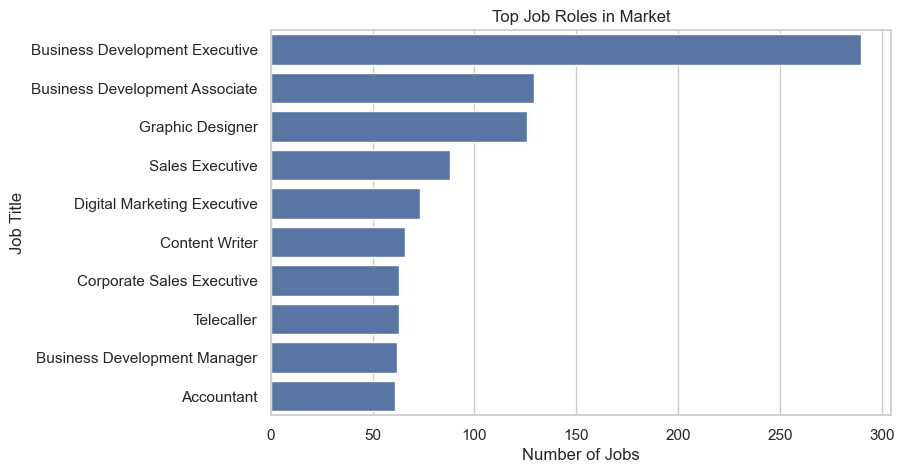

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(x=top_roles.values, y=top_roles.index)
plt.title("Top Job Roles in Market")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")
plt.show()

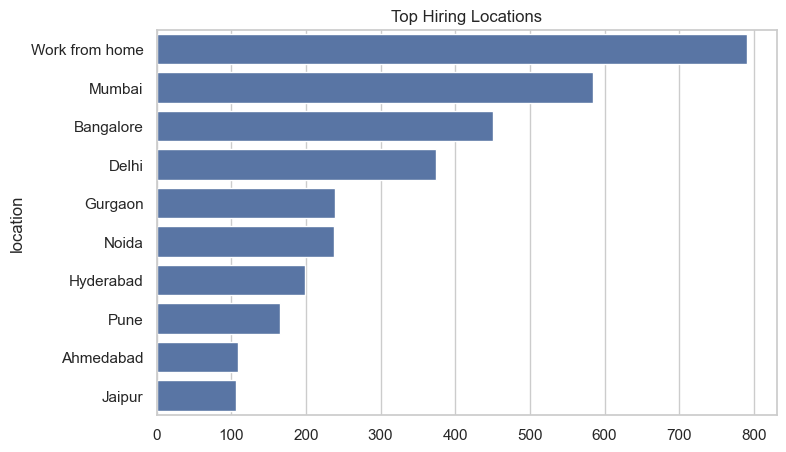

In [30]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top Hiring Locations")
plt.show()

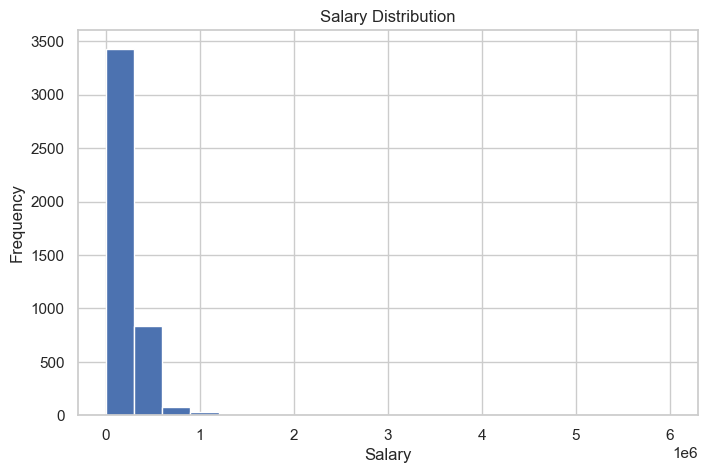

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df['min_salary'], bins=20)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

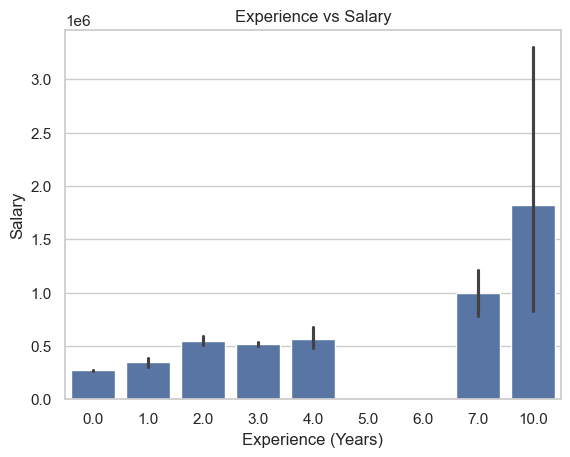

In [33]:
sns.barplot(data=df, x='min_exp', y='min_salary')
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.show()

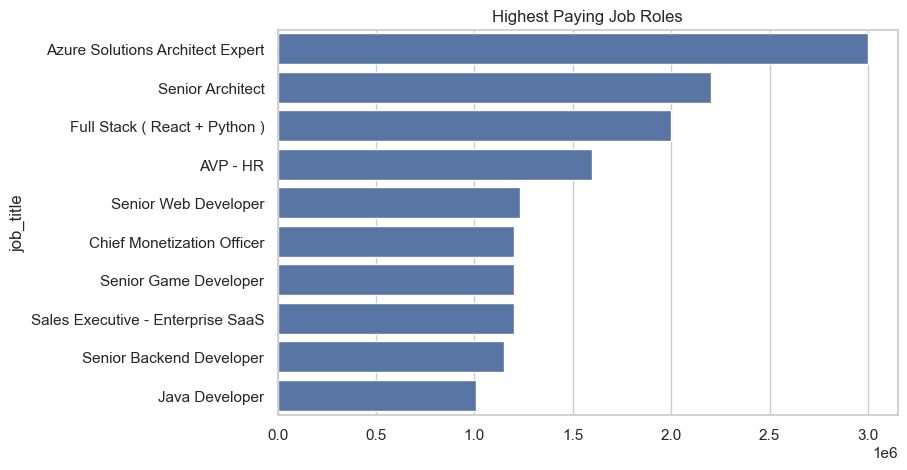

In [34]:
avg_salary_role = df.groupby('job_title')['min_salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_salary_role.values, y=avg_salary_role.index)
plt.title("Highest Paying Job Roles")
plt.show()

In [35]:
def extract_skills(title):
    skills = []
    title = title.lower()
    
    if 'python' in title:
        skills.append('Python')
    if 'data' in title:
        skills.append('Data Analysis')
    if 'marketing' in title:
        skills.append('Marketing')
    if 'sales' in title:
        skills.append('Sales')
    if 'designer' in title:
        skills.append('Design')
    if 'developer' in title:
        skills.append('Programming')
        
    return skills

df['skills'] = df['job_title'].apply(extract_skills)

# Flatten skills
all_skills = df['skills'].explode()

skill_counts = all_skills.value_counts()

print(skill_counts)

skills
Sales            587
Programming      430
Marketing        429
Design           293
Data Analysis    101
Python            29
Name: count, dtype: int64


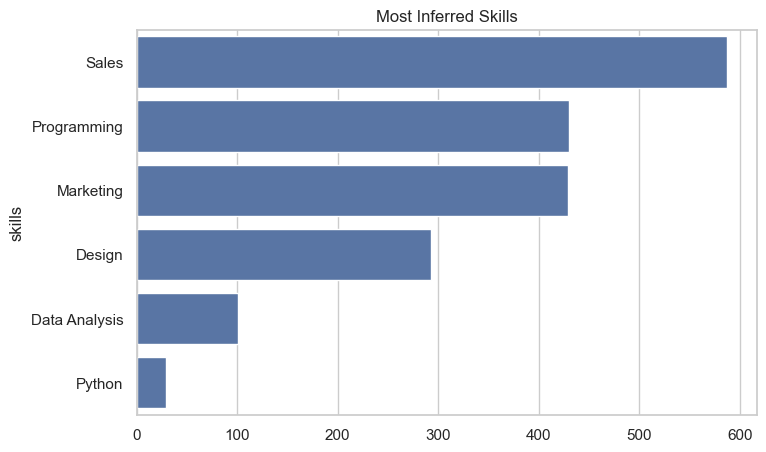

In [36]:
top_skills = skill_counts.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_skills.values, y=top_skills.index)
plt.title("Most Inferred Skills")
plt.show()

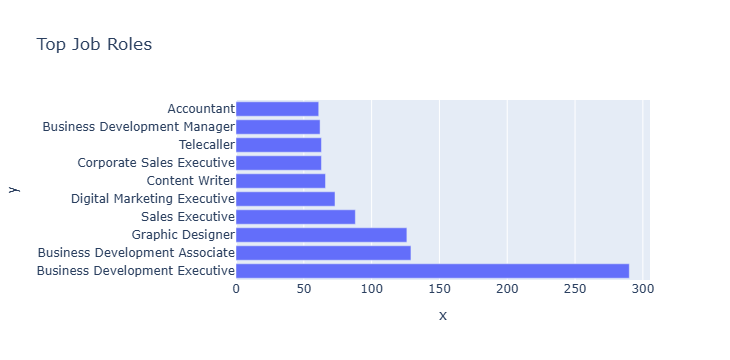

In [37]:
fig = px.bar(
    x=top_roles.values,
    y=top_roles.index,
    orientation='h',
    title="Top Job Roles"
)
fig.show()

In [38]:
def recommend_career(role):
    filtered = df[df['job_title'].str.contains(role, case=False)]
    
    avg_salary = filtered['min_salary'].mean()
    avg_exp = filtered['min_exp'].mean()
    
    return {
        "Average Salary": avg_salary,
        "Average Experience Required": avg_exp,
        "Top Locations": filtered['location'].value_counts().head(3).to_dict()
    }

print(recommend_career("Python"))

{'Average Salary': np.float64(461840.0), 'Average Experience Required': np.float64(1.206896551724138), 'Top Locations': {'Work from home': 5, 'Delhi': 3, 'Noida': 3}}
